In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

CWD: c:\Dev\Damage_Assessment_on_xBD\Model_Architectures Notebooks
Project root added: c:\Dev\Damage_Assessment_on_xBD


In [2]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from src.model_unet import UNet

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4070


In [4]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 8
LR = 2e-4
NUM_EPOCHS = 50
PATIENCE = 8
BASE_FEATURES = 32
SAVE_PATH = "best_unet_combo.pth"

In [5]:
# Create Data Splits
from ..Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 9820
Val: 1960
Test: 1912
Train: 9820  Val: 1960  Test: 1912


In [6]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, siamese=False, augment_train=False)

In [7]:
# Sanity check
images, masks = next(iter(train_loader))
print(f"Batch images: {images.shape}")  # [B, 9, H, W]
print(f"Batch masks:  {masks.shape}")   # [B, H, W]
print(f"Mask range:   {masks.min()} – {masks.max()}")
print(images.device)


Batch images: torch.Size([8, 6, 512, 512])
Batch masks:  torch.Size([8, 512, 512])
Mask range:   0 – 4
cpu


In [8]:
# Loss — ComboLoss (CE + Tversky)
class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()
weights = 1.0 / torch.sqrt(freqs)
weights = weights / weights.mean()
class_weights = weights.to(device)

In [9]:
# Model
model = UNet(
    in_channels=9, # include difference channels
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device) 

Model parameters: 7,764,037
cuda:0


In [10]:
# Loss, Optimizer, LR Scheduler (Define Here)
criterion = ComboLoss(class_weights=class_weights, ce_weight=0.5,
                      tversky_weight=0.5, tversky_alpha=0.7,
                      tversky_beta=0.3, num_classes=NUM_CLASSES).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

In [11]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True)



Epoch 1/50  (lr=2.00e-04)
  Train Loss: 0.7109  |  Val Loss: 0.5057
  Train mIoU: 0.2810  |  Val mIoU: 0.2994
  Train Acc:  0.8928  |  Val Acc:  0.9628
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9644   0.9865   0.9773
    Minor             0.4945   0.6237   0.7047
    Major             0.0027   0.0028   0.0857
    Destroyed         0.0060   0.0204   0.0083
    Unclassified      0.0292   0.0696   0.0480
  *** Saved new best model (mIoU=0.2994) ***



Epoch 2/50  (lr=1.81e-04)
  Train Loss: 0.5309  |  Val Loss: 0.4951
  Train mIoU: 0.3538  |  Val mIoU: 0.2882
  Train Acc:  0.9299  |  Val Acc:  0.9388
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9457   0.9937   0.9514
    Minor             0.4132   0.4940   0.7163
    Major             0.0020   0.0020   0.3315
    Destroyed         0.0129   0.0160   0.0622
    Unclassified      0.0674   0.1299   0.1230



Epoch 3/50  (lr=1.31e-04)
  Train Loss: 0.4850  |  Val Loss: 0.4386
  Train mIoU: 0.3881  |  Val mIoU: 0.3430
  Train Acc:  0.9396  |  Val Acc:  0.9683
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9697   0.9894   0.9798
    Minor             0.5624   0.6911   0.7512
    Major             0.0014   0.0015   0.0216
    Destroyed         0.0209   0.0274   0.0805
    Unclassified      0.1606   0.1870   0.5318
  *** Saved new best model (mIoU=0.3430) ***



Epoch 4/50  (lr=6.98e-05)
  Train Loss: 0.4537  |  Val Loss: 0.4608
  Train mIoU: 0.4245  |  Val mIoU: 0.3247
  Train Acc:  0.9456  |  Val Acc:  0.9599
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9645   0.9914   0.9726
    Minor             0.5141   0.6335   0.7318
    Major             0.0029   0.0029   0.2001
    Destroyed         0.0096   0.0098   0.2919
    Unclassified      0.1325   0.2711   0.2058



Epoch 5/50  (lr=2.00e-05)
  Train Loss: 0.4339  |  Val Loss: 0.4237
  Train mIoU: 0.4495  |  Val mIoU: 0.3624
  Train Acc:  0.9488  |  Val Acc:  0.9693
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9718   0.9916   0.9799
    Minor             0.5663   0.6745   0.7792
    Major             0.0021   0.0021   0.0562
    Destroyed         0.0207   0.0221   0.2444
    Unclassified      0.2512   0.4109   0.3925
  *** Saved new best model (mIoU=0.3624) ***


...


Epoch 18/50  (lr=1.95e-04)
  Train Loss: 0.4014  |  Val Loss: 0.4246
  Train mIoU: 0.4832  |  Val mIoU: 0.3558
  Train Acc:  0.9517  |  Val Acc:  0.9626
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9624   0.9939   0.9681
    Minor             0.5372   0.5816   0.8756
    Major             0.0050   0.0059   0.0325
    Destroyed         0.0069   0.0076   0.0631
    Unclassified      0.2675   0.4076   0.4376



Epoch 19/50  (lr=1.89e-04)
  Train Loss: 0.3890  |  Val Loss: 0.4194
  Train mIoU: 0.5023  |  Val mIoU: 0.3740
  Train Acc:  0.9538  |  Val Acc:  0.9718
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9727   0.9909   0.9814
    Minor             0.5906   0.6923   0.8007
    Major             0.0050   0.0054   0.0630
    Destroyed         0.0077   0.0082   0.0988
    Unclassified      0.2939   0.5660   0.3795



Epoch 20/50  (lr=1.81e-04)
  Train Loss: 0.3845  |  Val Loss: 0.4687
  Train mIoU: 0.5051  |  Val mIoU: 0.3094
  Train Acc:  0.9539  |  Val Acc:  0.9444
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9579   0.9953   0.9623
    Minor             0.3976   0.5504   0.5889
    Major             0.0024   0.0024   0.4014
    Destroyed         0.0072   0.0073   0.2880
    Unclassified      0.1817   0.2024   0.6398



Epoch 21/50  (lr=1.71e-04)
  Train Loss: 0.3791  |  Val Loss: 0.4398
  Train mIoU: 0.5142  |  Val mIoU: 0.3655
  Train Acc:  0.9547  |  Val Acc:  0.9726
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9750   0.9914   0.9834
    Minor             0.5936   0.7097   0.7840
    Major             0.0032   0.0033   0.1002
    Destroyed         0.0215   0.0251   0.1322
    Unclassified      0.2342   0.6943   0.2612



Epoch 22/50  (lr=1.59e-04)
  Train Loss: 0.3719  |  Val Loss: 0.4332
  Train mIoU: 0.5219  |  Val mIoU: 0.3579
  Train Acc:  0.9556  |  Val Acc:  0.9689
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9702   0.9923   0.9776
    Minor             0.5720   0.6530   0.8218
    Major             0.0084   0.0087   0.1769
    Destroyed         0.0125   0.0142   0.0918
    Unclassified      0.2264   0.4752   0.3018

Early stopping triggered after 22 epochs.


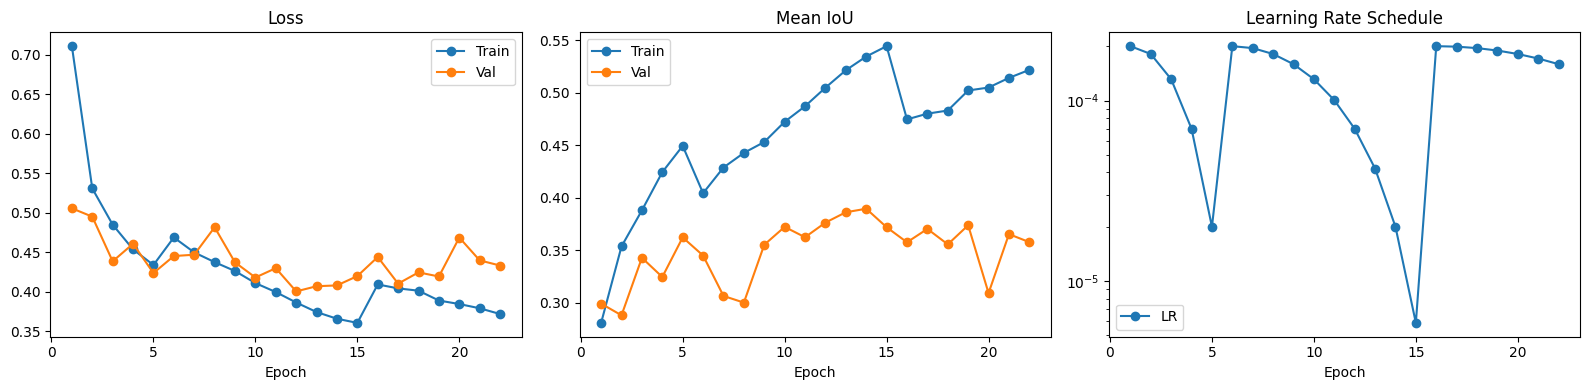

In [12]:
plot_train_history(history)

In [13]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES, siamese=False)

Test Loss: 0.9100
Test mIoU: 0.3194
Test Acc:  0.9183

Class                IoU     Prec   Recall
No Damage         0.9415   0.9683   0.9714
Minor             0.5796   0.6771   0.8009
Major             0.0423   0.1023   0.0673
Destroyed         0.0143   0.2078   0.0152
Unclassified      0.0191   0.0364   0.0386
